In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1️⃣  Download the CSV (no API key needed)
# -------------------------------------------------
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'])
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [2]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Passengers_scaled'] = scaler.fit_transform(df[['Passengers']])

In [3]:
LOOK_BACK = 12          # how many past steps we feed to the LSTM
TARGET_STEP = 1         # how many steps ahead we predict (1 = next month)

def create_sequences(values, look_back, target_step=1):
    """Turn a 1‑D array into (samples, timesteps, features) + target arrays."""
    X, y = [], []
    for i in range(len(values) - look_back - target_step + 1):
        X.append(values[i:(i + look_back)])
        y.append(values[(i + look_back + target_step - 1)])
    return np.array(X), np.array(y)

series = df['Passengers_scaled'].values.astype(np.float32)
X, y = create_sequences(series, LOOK_BACK, TARGET_STEP)

# reshape X to (samples, timesteps, features) – here features = 1
X = X.reshape((X.shape[0], X.shape[1], 1))
print(f'X shape: {X.shape}, y shape: {y.shape}')


VAL_RATIO = 0.2          # 20 % for validation
split_index = int(len(X) * (1 - VAL_RATIO))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f'Train samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}')

X shape: (132, 12, 1), y shape: (132,)
Train samples: 105, Validation samples: 27


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Force TensorFlow to use the CPU (optional – it will pick CPU if no GPU is found)
tf.config.set_visible_devices([], 'GPU')

In [5]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(LOOK_BACK, 1)),
    LSTM(50, activation='tanh', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Early stopping stops training once validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss',
                           patience=10,            # epochs with no improvement
                           restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=0
)

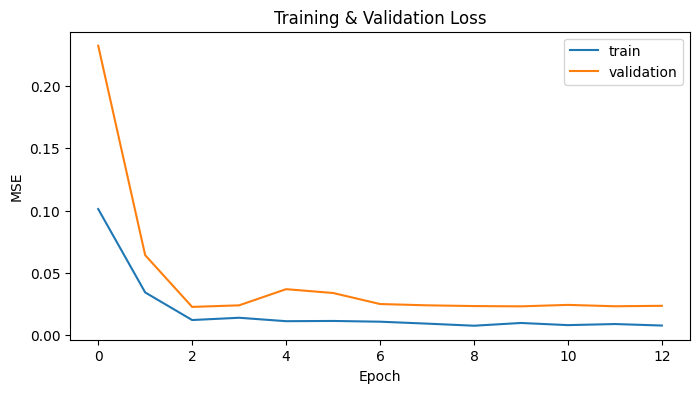

In [7]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


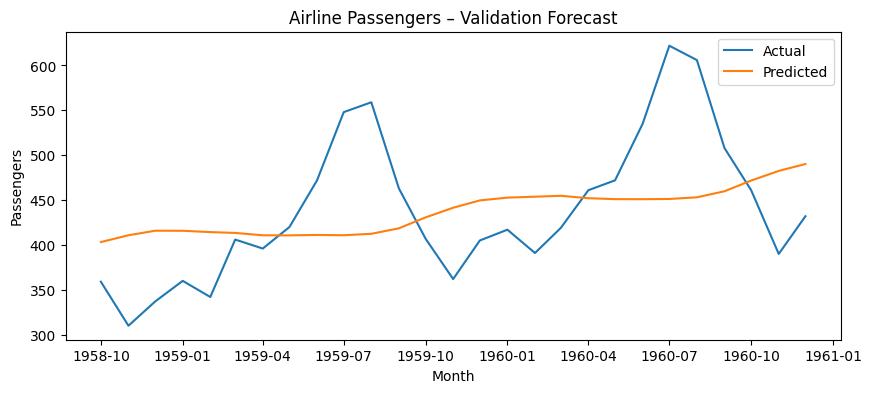

In [8]:
# Predict on the validation set (still scaled)
y_pred_scaled = model.predict(X_val)

# Inverse‑scale back to original passenger numbers
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_val.reshape(-1, 1))

# Simple visual check
plt.figure(figsize=(10,4))
plt.plot(df['Month'][split_index+LOOK_BACK:], y_true, label='Actual')
plt.plot(df['Month'][split_index+LOOK_BACK:], y_pred, label='Predicted')
plt.title('Airline Passengers – Validation Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

To be Improved:<br>
-2.1 Increase the look‑back to at least 12 (already done) and preferably 24 (two years)<br>
-2.2 Add a month‑of‑year feature (one‑hot or sinusoidal)<br>
-2.3 Detrend / Difference the series (optional but often helps)<br>
-2.4 Slightly enlarge the network (still tiny)<br>
-2.5 Adjust training callbacks<br>


In [9]:
# --------------------------------------------------
# 2️⃣  Feature engineering
# --------------------------------------------------
# 2.1  Month index (0‑11) and one‑hot encoding
df['month_idx'] = df['Month'].dt.month - 1
month_ohe = pd.get_dummies(df['month_idx'], prefix='m')
df = pd.concat([df, month_ohe], axis=1)

# 2.2  Scale the passenger count (target)
scaler = MinMaxScaler()
df['scaled'] = scaler.fit_transform(df[['Passengers']])

# -----------------------------------------------------------------
# 2.3  OPTIONAL: differencing (uncomment if you want to try it)
# -----------------------------------------------------------------
# df['diff'] = df['Passengers'].diff()
# df['diff'].iloc[0] = 0
# diff_scaler = MinMaxScaler()
# df['scaled'] = diff_scaler.fit_transform(df[['diff']])

# --------------------------------------------------
# 3️⃣  Build lag windows (look‑back = 24 months)
# --------------------------------------------------
LOOK_BACK = 24
TARGET_STEP = 1

feature_cols = ['scaled'] + [c for c in df.columns if c.startswith('m_')]
values = df[feature_cols].values.astype(np.float32)

def create_sequences(arr, look_back, step=1):
    X, y = [], []
    for i in range(len(arr) - look_back - step + 1):
        X.append(arr[i:i+look_back, :])          # all features
        y.append(arr[i+look_back+step-1, 0])    # target = scaled passenger column
    return np.array(X), np.array(y)

X, y = create_sequences(values, LOOK_BACK, TARGET_STEP)

# --------------------------------------------------
# 4️⃣  Train / validation split
# --------------------------------------------------
VAL_RATIO = 0.2
split = int(len(X)*(1-VAL_RATIO))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print(f"X shape: {X.shape}   y shape: {y.shape}")
print(f"Train samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}")

X shape: (120, 24, 13)   y shape: (120,)
Train samples: 96, Validation samples: 24


In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
# --------------------------------------------------
# 5️⃣  Model definition (two‑layer LSTM, small but enough)
# --------------------------------------------------
model = Sequential([
    Input(shape=(LOOK_BACK, X.shape[2])),
    LSTM(80, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),
    LSTM(40, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# --------------------------------------------------
# 6️⃣  Training – early stop + LR reduction
# --------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss',
                           patience=20,
                           restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                             factor=0.5,
                             patience=5,
                             min_lr=1e-5,
                             verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=8,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 80)         │        30,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 40)             │        19,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,481 (193.29 KB)

 Trainable params: 49,481 (193.29 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 50: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 55: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 60: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 65: ReduceLROnPlateau reducing learning rate to 1e-05.


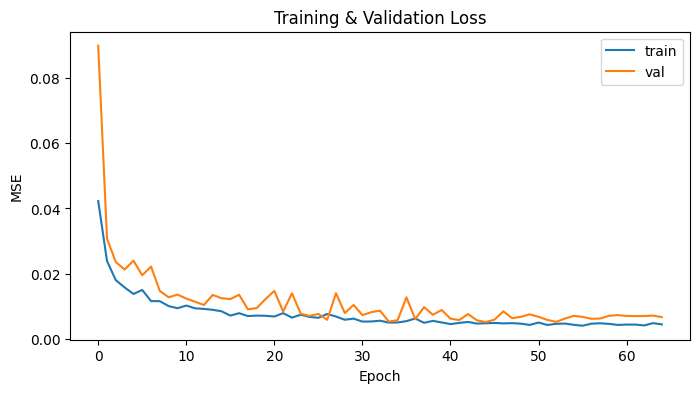

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step


In [11]:
# --------------------------------------------------
# 7️⃣  Plot loss curves
# --------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

# --------------------------------------------------
# 8️⃣  Forecast on the validation set
# --------------------------------------------------
y_pred_scaled = model.predict(X_val)

# Inverse‑scale back to original passengers
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_val.reshape(-1,1))

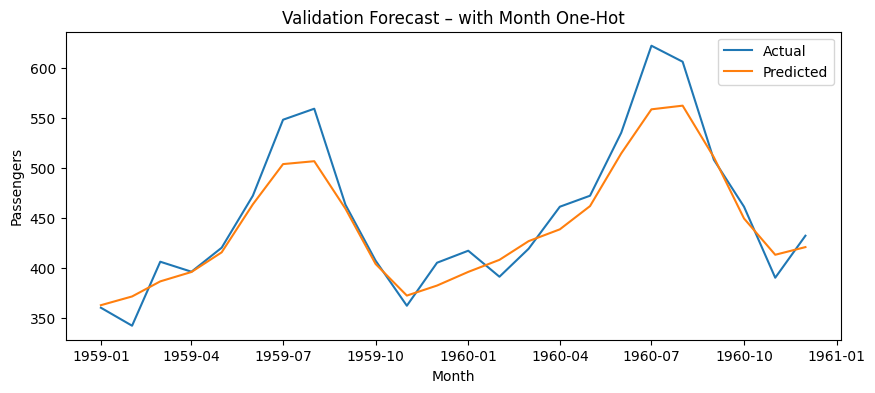

In [12]:
plt.figure(figsize=(10,4))
plt.plot(df['Month'][split+LOOK_BACK:], y_true, label='Actual')
plt.plot(df['Month'][split+LOOK_BACK:], y_pred, label='Predicted')
plt.title('Validation Forecast – with Month One‑Hot')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()